# Temporal review trend for popular products, bundle product

## By M11351015 李國禎

In [209]:
from pymongo import MongoClient
from collections import defaultdict
import pprint
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from datetime import datetime

mongo_uri = 'mongodb://localhost:27017/'
database_name = 'mydatabase'

client = MongoClient(mongo_uri)
db = client[database_name]
reviews_col = db['reviews']
products_col = db['products']

def analyze_field_types(collection_name, sample_size=5):
    print(f"\n[分析 Collection: {collection_name} 的欄位與型別]")
    collection = db[collection_name]
    samples = collection.find().limit(sample_size)

    field_types = defaultdict(set)

    for doc in samples:
        for key, value in doc.items():
            field_types[key].add(type(value).__name__)  # 顯示型別名稱

    # 輸出結果
    for field, types in field_types.items():
        print(f"{field}: {', '.join(types)}")

# 執行分析
#analyze_field_types('products')
analyze_field_types('reviews')



[分析 Collection: reviews 的欄位與型別]
_id: ObjectId
ProductId: str
UserId: str
ProfileName: str
HelpfulnessNumerator: int
HelpfulnessDenominator: int
Score: int
Time: int
Summary: str
Text: str
Keywords: list
Lemmas: list
Named_entities: list
POS_tags: list
Sentiment_score: float
Text_cleaned: str
Tokens: list
Tokens_processed: list


In [210]:
def show_reviews_by_product(product_id, limit=5):
    print(f"\n[顯示產品 {product_id} 的前 {limit} 筆評論]")
    cursor = reviews_col.find({'ProductId': product_id}).limit(limit)

    for i, doc in enumerate(cursor, 1):
        print(f"\n第{i}筆資料:")
        pprint.pprint(doc)


In [ ]:
show_reviews_by_product('B002QWP8H0', limit=1)


[顯示產品 B002QWP8H0 的前 1 筆評論]

第1筆資料:
{'HelpfulnessDenominator': 1,
 'HelpfulnessNumerator': 1,
 'Keywords': ['chronic brochotitis',
              'fits at night',
              'coughing fits',
              'brochotitis',
              'night',
              'sheltie',
              'chronic',
              'coughing',
              'fits',
              'year'],
 'Lemmas': ['12',
            'year',
            'old',
            'sheltie',
            'chronic',
            'brochotitis',
            'med',
            'year',
            'help',
            'coughing',
            'fit',
            'night',
            'like',
            'them!!!<br',
            '>',
            'bite',
            'dog',
            'addicted',
            'warn',
            '7',
            'pm',
            'sheltie',
            'lap',
            'howl',
            'drug',
            'fix',
            'dog',
            'trainer',
            'see',
            ' ',
            'like',
 

In [ ]:
limit =15

# 對每個產品進行彙總（計算平均評分與評分人數）
aggregated_products = reviews_col.aggregate([
    {
        "$group": {
            "_id": "$ProductId",
            "average_rating": {"$avg": "$Score"},
            "rating_number": {"$sum": 1}
        }
    }
])

# 將結果轉成 list 方便後續處理
aggregated_products_list = list(aggregated_products)

# 排序評分人數最多的產品（取前 15 名）
top_rated_by_reviews_list = sorted(
    aggregated_products_list,
    key=lambda x: x["rating_number"],
    reverse=True
)[:limit]

# 排序平均評分最高的產品（取前 10 名）
top_rated_by_average_list = sorted(
    aggregated_products_list,
    key=lambda x: x["average_rating"],
    reverse=True
)[:10]

# 輸出結果
print("評分人數最多的15項產品:")
for idx, item in enumerate(top_rated_by_reviews_list, 1):
    print(f"{idx}. ASIN: {item['_id']}, 平均評分: {item['average_rating']:.2f}, 評分人數: {item['rating_number']}")



評分人數最多的15項產品:
1. ASIN: B007JFMH8M, 平均評分: 4.58, 評分人數: 913
2. ASIN: B002QWP89S, 平均評分: 4.59, 評分人數: 632
3. ASIN: B002QWP8H0, 平均評分: 4.59, 評分人數: 632
4. ASIN: B0026RQTGE, 平均評分: 4.59, 評分人數: 632
5. ASIN: B002QWHJOU, 平均評分: 4.59, 評分人數: 632
6. ASIN: B003B3OOPA, 平均評分: 4.74, 評分人數: 623
7. ASIN: B001EO5Q64, 平均評分: 4.75, 評分人數: 567
8. ASIN: B0013NUGDE, 平均評分: 4.31, 評分人數: 564
9. ASIN: B001RVFEP2, 平均評分: 4.31, 評分人數: 564
10. ASIN: B0026KPDG8, 平均評分: 4.31, 評分人數: 564
11. ASIN: B006HYLW32, 平均評分: 4.31, 評分人數: 564
12. ASIN: B0026KNQSA, 平均評分: 4.31, 評分人數: 564
13. ASIN: B000VK8AVK, 平均評分: 4.31, 評分人數: 564
14. ASIN: B001RVFERK, 平均評分: 4.31, 評分人數: 564
15. ASIN: B007M832YY, 平均評分: 4.31, 評分人數: 564


In [214]:
# 步驟 1：找出評論數最多的前幾個 ProductId
top_products = reviews_col.aggregate([
    {
        "$group": {
            "_id": "$ProductId",
            "review_count": {"$sum": 1}
        }
    },
    {
        "$sort": {"review_count": -1}
    },
    {
        "$limit": limit
    }
])

top_product_ids = [doc["_id"] for doc in top_products]

# 步驟 2：統計這幾幾個 ProductId 每個月的平均分數
results = []

for pid in top_product_ids:
    pipeline = [
        {
            "$match": {
                "ProductId": pid,
                "Score": {"$ne": None},
                "Time": {"$ne": None}
            }
        },
        {
            "$project": {
                "Score": 1,
                "year": {"$year": {"$toDate": {"$multiply": ["$Time", 1000]}}},
                "month": {"$month": {"$toDate": {"$multiply": ["$Time", 1000]}}}
            }
        },
        {
            "$group": {
                "_id": {
                    "year": "$year",
                    "month": "$month"
                },
                "average_score": {"$avg": "$Score"}
            }
        },
        {
            "$sort": {
                "_id.year": 1,
                "_id.month": 1
            }
        }
    ]

    monthly_stats = list(reviews_col.aggregate(pipeline))
    monthly_ratings = [
        {
            "month": f"{item['_id']['year']}-{item['_id']['month']:02d}",
            "average_score": round(item["average_score"], 2)
        }
        for item in monthly_stats
    ]

    results.append({
        "ProductId": pid,
        "monthly_ratings": monthly_ratings
    })

# 顯示結果
import pprint
pprint.pprint(results, sort_dicts=False)

[{'ProductId': 'B007JFMH8M',
  'monthly_ratings': [{'month': '2012-07', 'average_score': 4.65},
                      {'month': '2012-08', 'average_score': 3.39},
                      {'month': '2012-09', 'average_score': 3.57},
                      {'month': '2012-10', 'average_score': 4.5}]},
 {'ProductId': 'B002QWP8H0',
  'monthly_ratings': [{'month': '2007-03', 'average_score': 5.0},
                      {'month': '2008-04', 'average_score': 5.0},
                      {'month': '2008-06', 'average_score': 5.0},
                      {'month': '2008-08', 'average_score': 5.0},
                      {'month': '2008-10', 'average_score': 5.0},
                      {'month': '2008-11', 'average_score': 2.0},
                      {'month': '2009-01', 'average_score': 4.67},
                      {'month': '2009-02', 'average_score': 5.0},
                      {'month': '2009-03', 'average_score': 4.67},
                      {'month': '2009-04', 'average_score': 5.0},
           

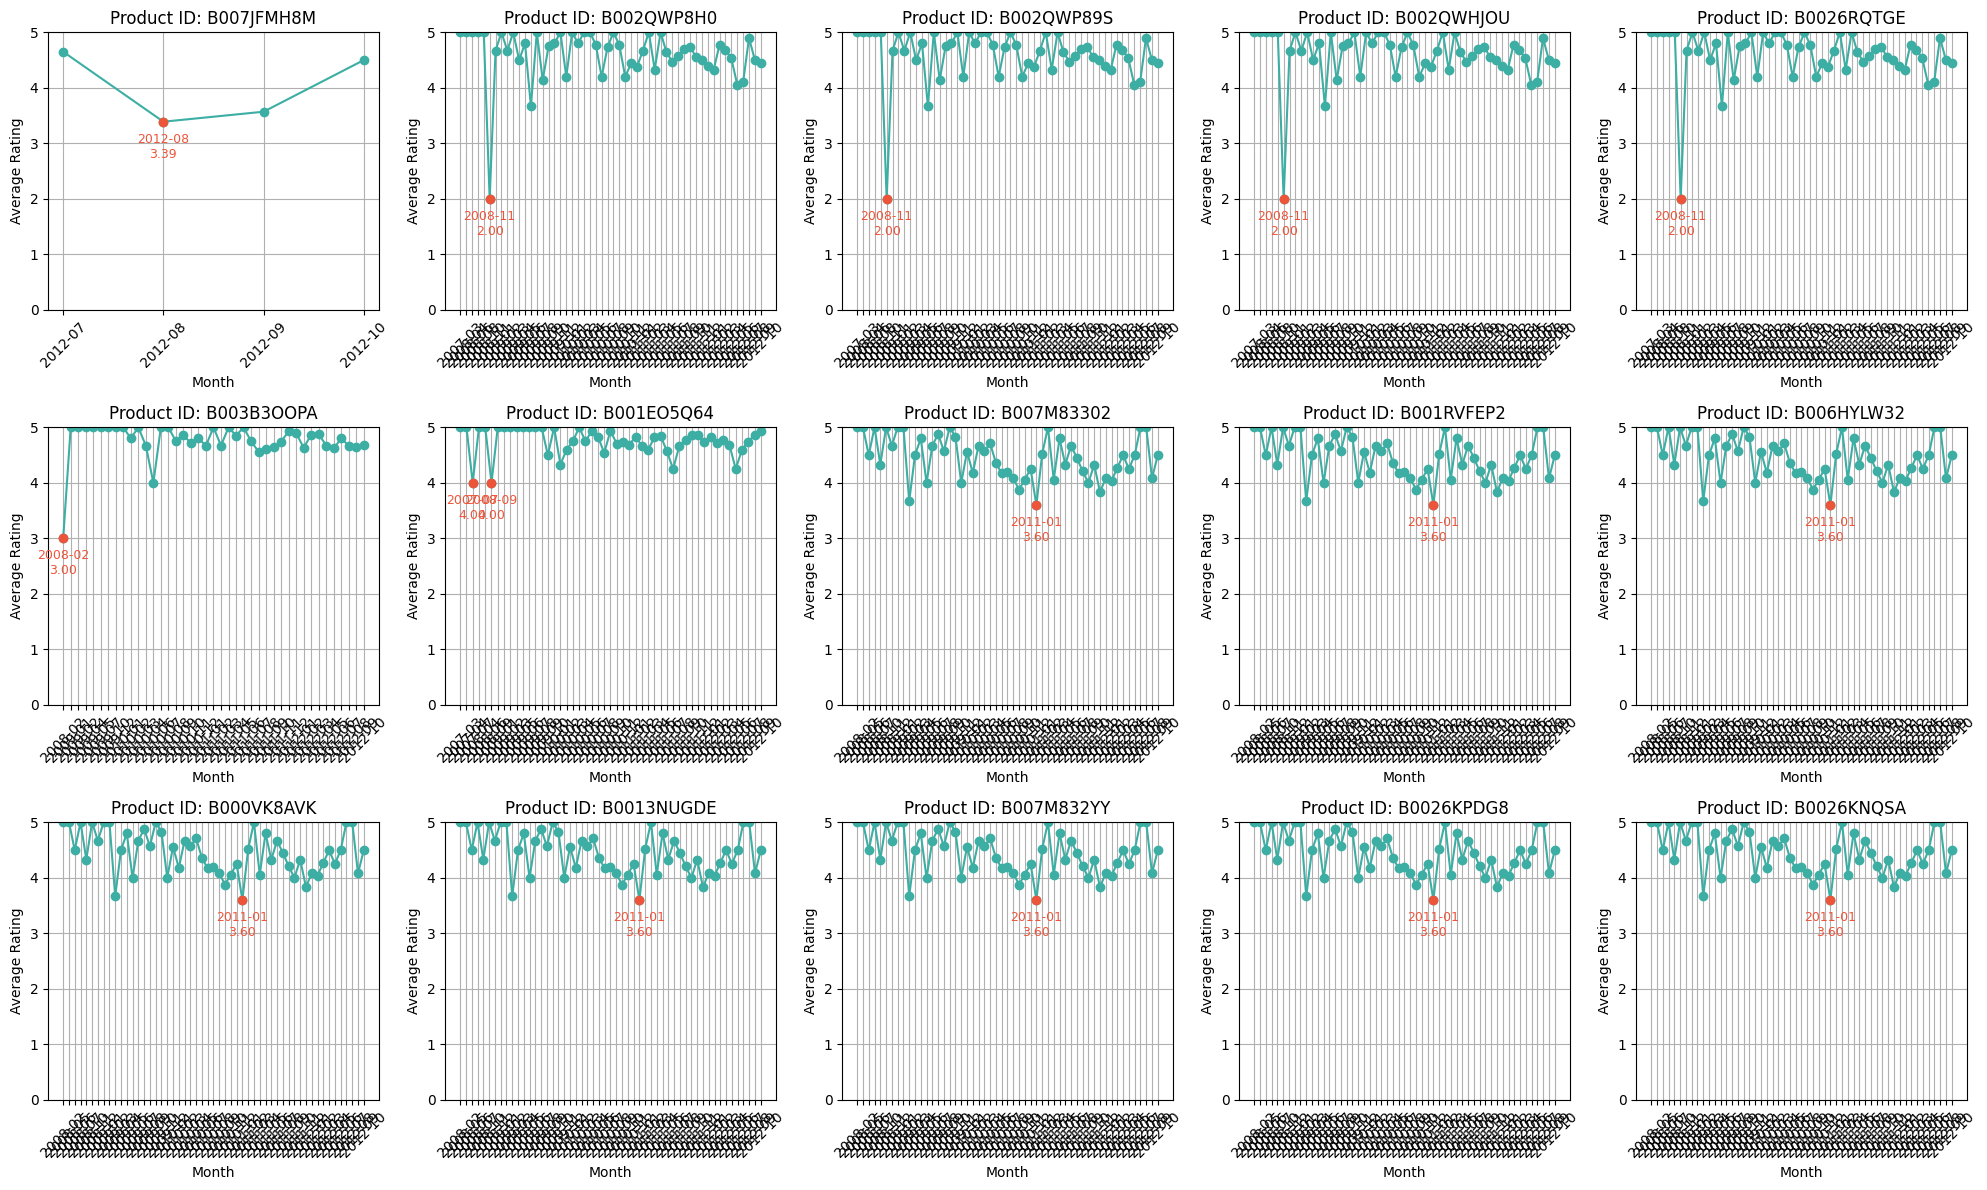

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(20, 12))  # 3 rows, 5 columns
axes = axes.flatten()  # 展開axes矩陣以便迭代

for idx, product in enumerate(results):
    if idx >= 15:
        break
    
    product_id = product["ProductId"]
    monthly_data = product["monthly_ratings"]
    
    if not monthly_data:
        continue  

    months = [item["month"] for item in monthly_data]
    scores = [item["average_score"] for item in monthly_data]

    min_score = min(scores)
    min_indices = [i for i, score in enumerate(scores) if score == min_score]
    min_months = [months[i] for i in min_indices]

    ax = axes[idx]  # 使用對應的子圖
    ax.plot(months, scores, marker='o', linestyle='-', color='#3CAEA3')  

    for i, min_index in enumerate(min_indices):
        min_month = months[min_index]
        ax.plot(min_month, min_score, 'o', color='#ED553B')  # 點的顏色改為橙色
        
        vertical_offset = 0.2
        label_text = f'{min_month}\n{min_score:.2f}'
        ax.text(min_month, min_score - vertical_offset, label_text, 
                color='#ED553B', ha='center', va='top', fontsize=9)  # 文字顏色改為橙色

    ax.set_title(f'Product ID: {product_id}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Rating')
    ax.set_ylim(0, 5)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)

# 自動調整布局以避免重疊
plt.tight_layout()
plt.show()


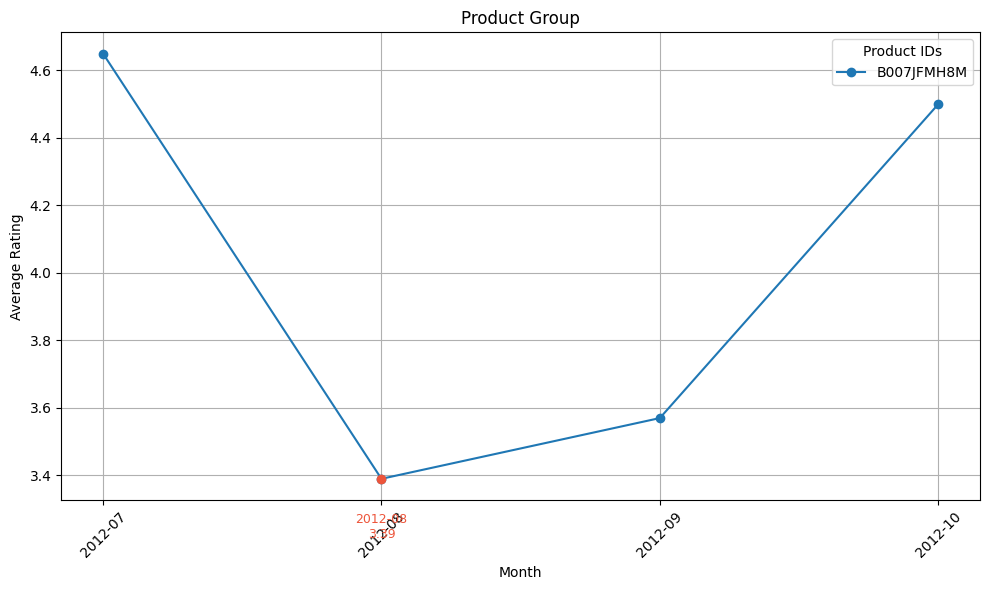

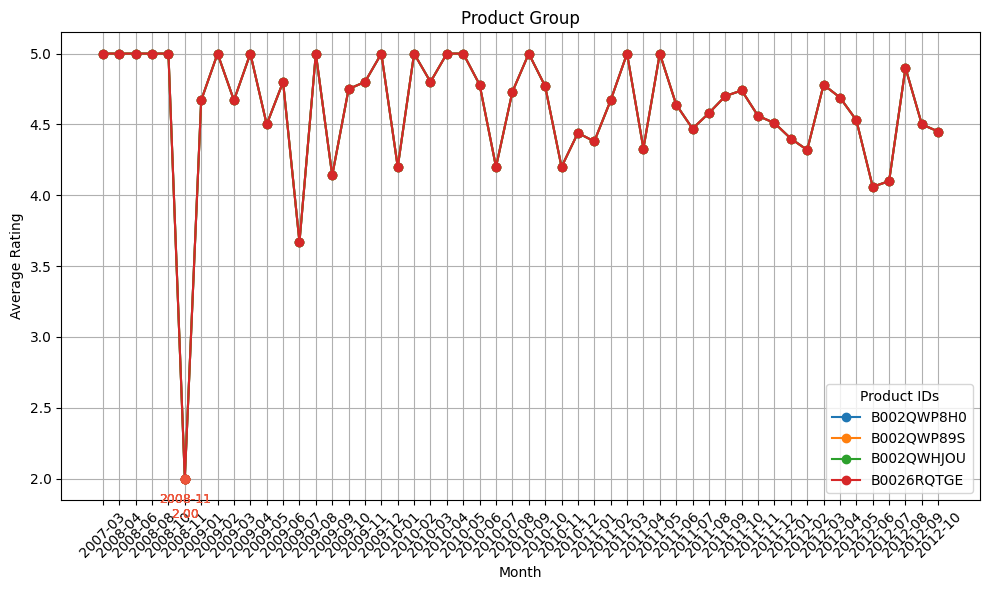

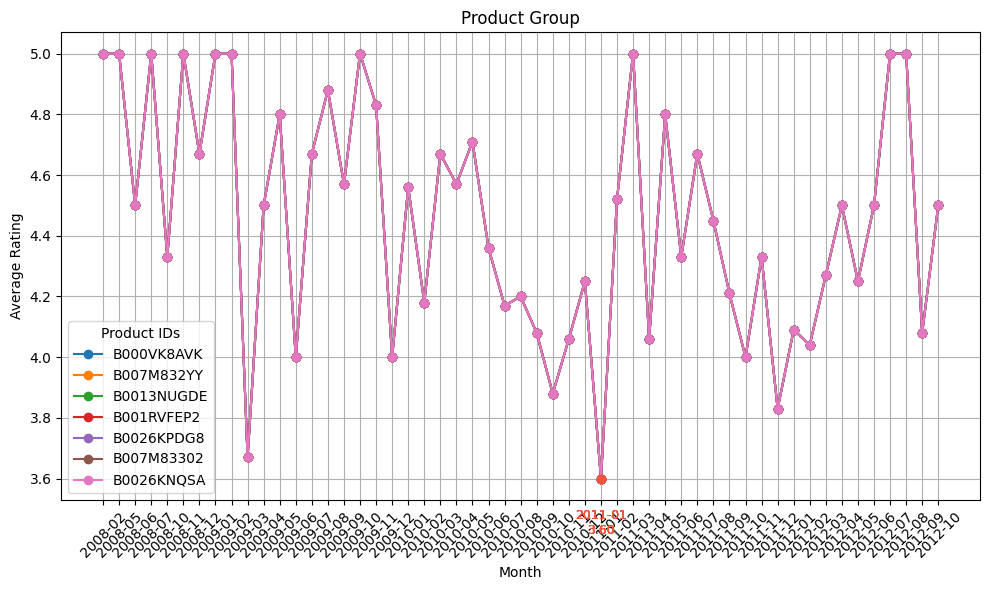

In [249]:
import matplotlib.pyplot as plt

# 三組產品的 ProductId
product_groups = [
    ["B007JFMH8M"],  # 第一組
    ["B002QWP8H0", "B002QWP89S", "B002QWHJOU", "B0026RQTGE"],  # 第二組
    ["B000VK8AVK", "B001RVFERK", "B007M832YY", "B0013NUGDE", "B001RVFEP2", "B0026KPDG8", "B007M83302", "B0026KNQSA"]  # 第三組
]

# 假設 `results` 已經是從先前程式碼中獲得的結果，並且每個結果中包含了 "ProductId" 和 "monthly_ratings"
# 你需要確保 `results` 中包含每組的 `ProductId` 和相對應的 `monthly_ratings`

for idx, product_group in enumerate(product_groups):
    plt.figure(figsize=(10, 6))  # 為每一組資料創建一個新的圖表
    plt.title(f"Product Group")

    # 迭代每組中的每個產品
    for product_id in product_group:
        # 查找該產品的每月評分資料
        product = next((prod for prod in results if prod["ProductId"] == product_id), None)

        if product and product.get("monthly_ratings"):
            monthly_data = product["monthly_ratings"]
            months = [item["month"] for item in monthly_data]
            average_scores = [item["average_score"] for item in monthly_data]

            # 檢查是否有資料
            if months and average_scores:
                # 繪製該產品的趨勢圖
                plt.plot(months, average_scores, marker='o', linestyle='-', label=product_id)

                # 標註最低分
                min_score = min(average_scores)
                min_month = months[average_scores.index(min_score)]
                plt.plot(min_month, min_score, 'o', color='#ED553B')  # 低分點
                plt.text(min_month, min_score - 0.1, f'{min_month}\n{min_score:.2f}', color='#ED553B', ha='center', va='top', fontsize=9)

    # 設置標題和標籤
    plt.xlabel('Month')
    plt.ylabel('Average Rating')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Product IDs")

    # 顯示圖表
    plt.tight_layout()
    plt.show()


In [216]:
import matplotlib.pyplot as plt

for product in results:
    product_id = product["ProductId"]
    monthly_data = product["monthly_ratings"]
    
    if not monthly_data:
        continue  

    months = [item["month"] for item in monthly_data]
    scores = [item["average_score"] for item in monthly_data]

    min_score = min(scores)
    min_indices = [i for i, score in enumerate(scores) if score == min_score]
    min_months = [months[i] for i in min_indices]

    # 印出最差月份與分數
    for min_month in min_months:
        print(f"產品 {product_id} 最差月份: {min_month}, 平均分數: {min_score:.2f}")

產品 B007JFMH8M 最差月份: 2012-08, 平均分數: 3.39
產品 B002QWP8H0 最差月份: 2008-11, 平均分數: 2.00
產品 B002QWP89S 最差月份: 2008-11, 平均分數: 2.00
產品 B002QWHJOU 最差月份: 2008-11, 平均分數: 2.00
產品 B0026RQTGE 最差月份: 2008-11, 平均分數: 2.00
產品 B003B3OOPA 最差月份: 2008-02, 平均分數: 3.00
產品 B001EO5Q64 最差月份: 2007-07, 平均分數: 4.00
產品 B001EO5Q64 最差月份: 2008-09, 平均分數: 4.00
產品 B007M83302 最差月份: 2011-01, 平均分數: 3.60
產品 B001RVFEP2 最差月份: 2011-01, 平均分數: 3.60
產品 B006HYLW32 最差月份: 2011-01, 平均分數: 3.60
產品 B000VK8AVK 最差月份: 2011-01, 平均分數: 3.60
產品 B0013NUGDE 最差月份: 2011-01, 平均分數: 3.60
產品 B007M832YY 最差月份: 2011-01, 平均分數: 3.60
產品 B0026KPDG8 最差月份: 2011-01, 平均分數: 3.60
產品 B0026KNQSA 最差月份: 2011-01, 平均分數: 3.60


### 探討2008-11 和 2011-01為什麼平價會那麼低


In [ ]:
from datetime import datetime

def get_timestamp_range(year, month):
    start = int(datetime(year, month, 1).timestamp())
    if month == 12:
        end = int(datetime(year + 1, 1, 1).timestamp())
    else:
        end = int(datetime(year, month + 1, 1).timestamp())
    return start, end

def find_reviews_by_product_and_time(reviews_col, product_ids, year, month):
    """
    查詢指定產品 ID 並在指定年月的評論。
    """
    start, end = get_timestamp_range(year, month)
    query = {
        "ProductId": {"$in": product_ids},
        "Time": {"$gte": start, "$lt": end}
    }
    return list(reviews_col.find(query))

# 定義產品 ID 與對應月份
query_conditions = {
    "2012-08": ["B007JFMH8M"],
    "2008-11": ["B002QWP8H0", "B002QWP89S", "B002QWHJOU", "B0026RQTGE"],
    "2008-02": ["B003B3OOPA"],
    "2007-07": ["B001EO5Q64"],
    "2008-09": ["B001EO5Q64", "B000KV61FC"],
    "2011-01": ["B000VK8AVK", "B001RVFERK", "B007M832YY", "B0013NUGDE",
                "B001RVFEP2", "B0026KPDG8", "B007M83302", "B0026KNQSA"]
}


# 把所有結果存成 dict 方便使用
all_reviews_by_month = {}

for ym, pid_list in query_conditions.items():
    year, month = map(int, ym.split("-"))
    reviews = find_reviews_by_product_and_time(reviews_col, pid_list, year, month)
    all_reviews_by_month[ym] = reviews

# 範例：顯示某個月份的所有評論筆數
for ym, reviews in all_reviews_by_month.items():
    print(f"{ym} 的評論數量: {len(reviews)}")


2012-08 的評論數量: 41
2008-11 的評論數量: 4
2008-02 的評論數量: 1
2007-07 的評論數量: 1
2008-09 的評論數量: 8
2011-01 的評論數量: 80


In [218]:
from datetime import datetime
from collections import defaultdict
import re

# 工具函數：清除 HTML
def clean_html(text):
    return re.sub(r'<.*?>', '', text)

# 顯示整理過的低分評論
def print_reviews_cleaned(reviews, show_tokens=False):
    low_score_threshold = 3
    product_reviews = defaultdict(list)

    for review in reviews:
        product_id = review.get("ProductId", "")
        score = review.get("Score", 0)
        if score <= low_score_threshold:
            product_reviews[product_id].append(review)

    merged_reviews = defaultdict(list)

    for product_id, revs in product_reviews.items():
        for review in revs:
            cleaned_text = clean_html(review.get("Text", ""))
            summary = review.get("Summary", "")
            score = review.get("Score", 0)
            merged_reviews[(cleaned_text, summary)].append((product_id, score))

    for (text, summary), prod_score_list in merged_reviews.items():
        unique_ids = list(set([pid for pid, _ in prod_score_list]))
        product_ids_str = ", ".join(unique_ids)
        scores = [s for _, s in prod_score_list]
        avg_score = sum(scores) / len(scores)

        print(f"商品: {product_ids_str}, 分數: {avg_score:.1f}")
        print(f"摘要: {summary}")
        print(f"評論: {text}")
        print("-" * 40)
        print(f"{product_ids_str} 商品共有 {len(prod_score_list)} 個低分評論。")
        print("-" * 40)



# 撈出所有符合的評論，然後印出
for ym, pids in query_conditions.items():
    year, month = map(int, ym.split("-"))
    reviews = find_reviews_by_product_and_time(reviews_col, pids, year, month)
    print(f"\n📆 處理 {ym} 的產品 {pids}（共 {len(reviews)} 筆評論）")
    print_reviews_cleaned(reviews)



📆 處理 2012-08 的產品 ['B007JFMH8M']（共 41 筆評論）
商品: B007JFMH8M, 分數: 3.0
摘要: Like the vending machine
評論: These large cookies greatly resemble in look and taste the ones you might get in a vending machine.  They are individually packaged and have a soft and chewy texture.  The taste left me pretty unsatisfied as they were pretty bland and tasted too "processed," not like simple and fresh oatmeal raisin cookies.  I would not recommend them personally, although my little ones liked them fine (although I rarely know kids to say "no" to a cookie!).
----------------------------------------
B007JFMH8M 商品共有 1 個低分評論。
----------------------------------------
商品: B007JFMH8M, 分數: 3.0
摘要: individually wrapped
評論: I've always on the lookout for handy snacks for my teenage son.  he loves soft cookies, so I was thrilled to see the soft baked oatmeal cookie from the masters of oatmeal.  My expectations were high.This is a good cookie, but not a great one, so I was a little disappointed.  The consistency is 

In [220]:
from collections import Counter

def get_negative_lemma_frequencies(reviews, threshold=3):
    lemma_counter = Counter()
    for review in reviews:
        if review.get("Score", 0) <= threshold:
            lemmas = review.get("Lemmas", [])
            lemma_counter.update(lemmas)
    return lemma_counter.most_common(50)  # 前 50 常見 Lemmas


In [236]:
import matplotlib.pyplot as plt

# 繪製詞頻長條圖
def plot_top_words(word_freq, title="Top Frequent Words"):
    words, counts = zip(*word_freq)  # 拆解詞和對應的頻率
    plt.figure(figsize=(12, 6))
    plt.bar(words, counts, color="#3CAEA3")  # 設定顏色為 #3CAEA3
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.tight_layout()  # 自動調整布局避免文字重疊
    plt.show()

In [242]:
# 停用詞清單
custom_stopwords = {"year", "old", "product", "use", "buy", "get", "one", "like", " ","/><br", "$", "<", "/>27", "br"}

# 計算並過濾掉不需要的停用詞
def get_cleaned_negative_frequencies(reviews, threshold=3, stopwords=custom_stopwords):
    lemma_counter = Counter()
    for review in reviews:
        if review.get("Score", 0) <= threshold:
            lemmas = [w for w in review.get("Lemmas", []) if w not in stopwords]
            lemma_counter.update(lemmas)
    return lemma_counter.most_common(50)


📅 Analyzing products ['B007JFMH8M'] for 2012-08 (41 reviews total)
Lemma 頻率資料: [('cookie', 67), ('taste', 24), ('oatmeal', 18), ('good', 15), ('raisin', 12), ('eat', 12), ('Quaker', 11), ('dry', 11), ('calorie', 10), ('flavor', 10), ('box', 10), ('soft', 9), ('texture', 9), ('find', 9), ('ingredient', 8), ('package', 7), ('recommend', 7), ('little', 7), ('want', 7), ('170', 7), ('try', 7), ('contain', 7), ('bland', 6), ('bite', 6), ('sugar', 6), ('individually', 5), ('pretty', 5), ('love', 5), ('bake', 5), ('/>i', 5), ('give', 5), ('come', 5), ('think', 5), ('need', 5), ('oat', 5), ('grain', 5), ('kid', 4), ('snack', 4), ('great', 4), ('expect', 4), ('bad', 4), ('right', 4), ('wrap', 4), ('moist', 4), ('open', 4), ('milk', 4), ('enjoy', 4), ('pack', 4), ('individual', 4), ('look', 3)]


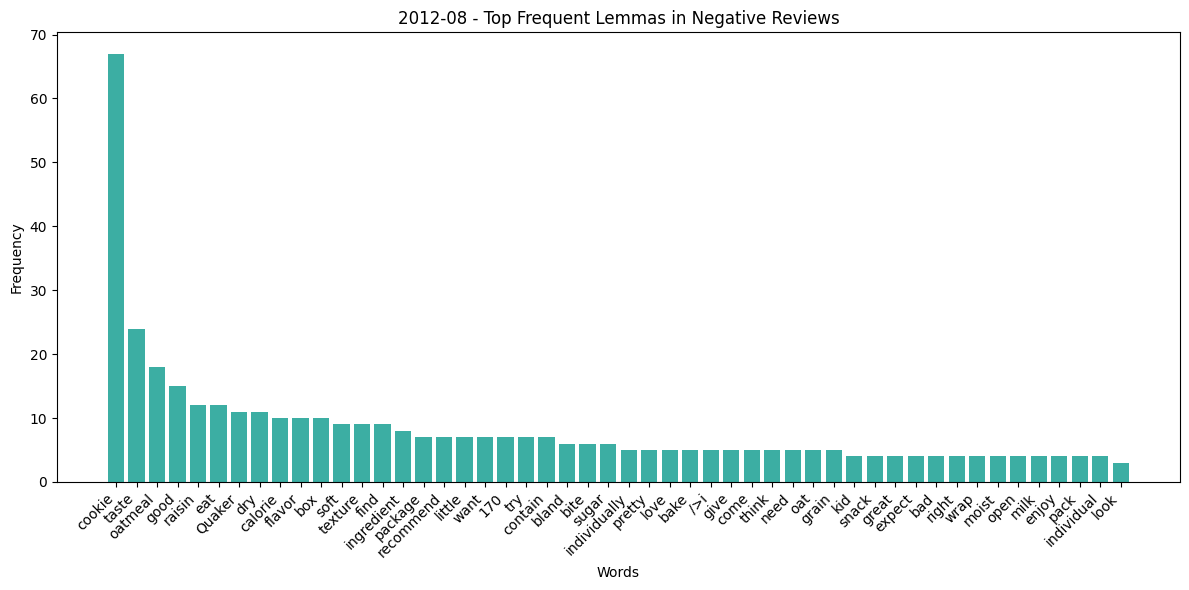


📅 Analyzing products ['B002QWP8H0', 'B002QWP89S', 'B002QWHJOU', 'B0026RQTGE'] for 2008-11 (4 reviews total)
Lemma 頻率資料: [('say', 8), ('greenie', 8), ('ad', 4), ('30', 4), ('regular', 4), ('package', 4), ('receive', 4)]


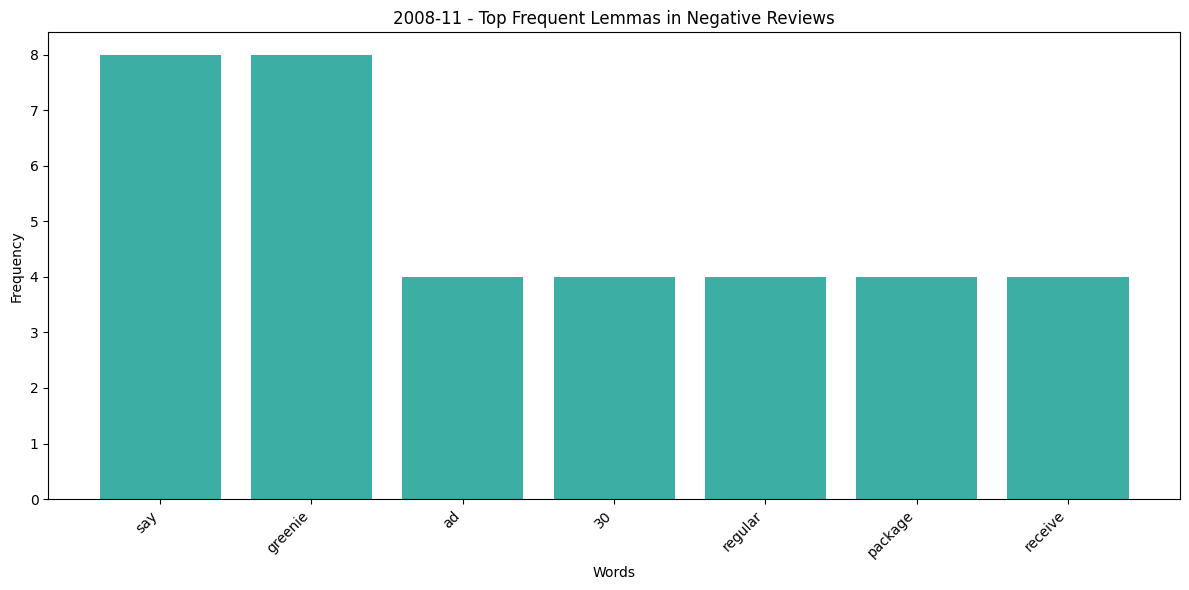


📅 Analyzing products ['B003B3OOPA'] for 2008-02 (1 reviews total)
Lemma 頻率資料: [('oil', 2), ('suppose', 1), ('healthy', 1), ('good', 1), ('packaging', 1), ('solidify', 1), ('greasy', 1), ('mess', 1), ('remove', 1), ('container', 1), ('make', 1), ('squeeze', 1), ('bottle', 1), ('easy', 1)]


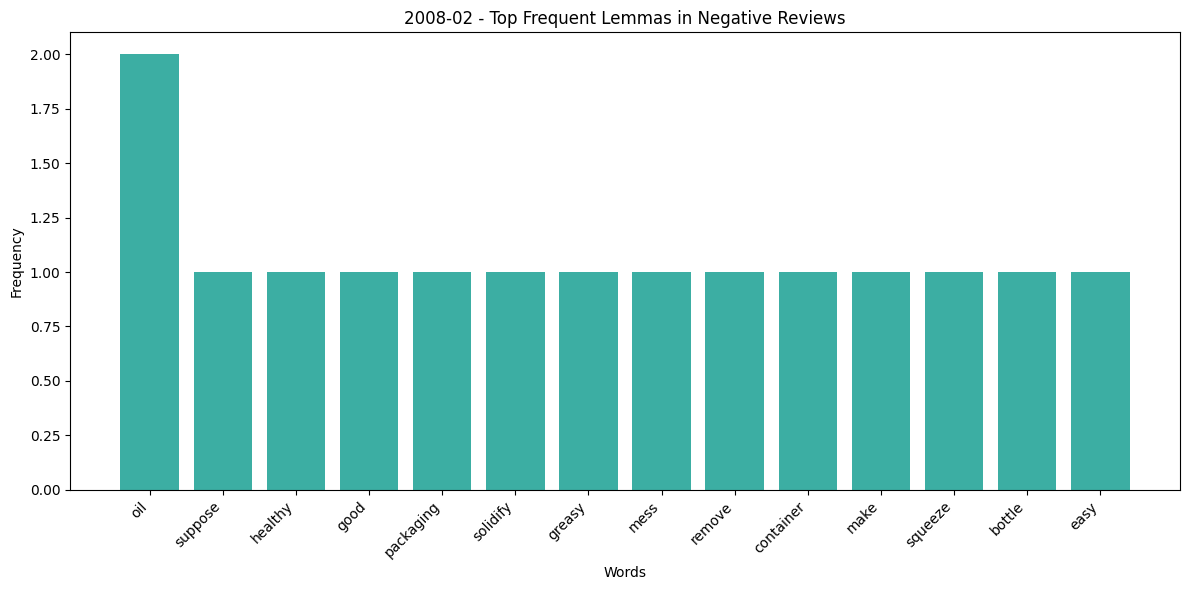


📅 Analyzing products ['B001EO5Q64'] for 2007-07 (1 reviews total)
Lemma 頻率資料: []
2007-07 沒有找到 Lemma！

📅 Analyzing products ['B001EO5Q64', 'B000KV61FC'] for 2008-09 (8 reviews total)
Lemma 頻率資料: [('rope', 4), ('dog', 3), ('chew', 3), ('treat', 3), ('toy', 3), ('medium', 2), ('pound', 2), ('thing', 2), ('think', 2), ('smell', 2), ('20', 2), ('start', 2), ('break', 2), ('piece', 2), ('large', 2), ('good', 2), ('jug', 2), ('puppy', 2), ('2', 2), ('try', 2), ('size', 1), ('38', 1), ('enjoy', 1), ('heavy', 1), ('chewer', 1), ('night', 1), ('receive', 1), ('excited', 1), ('tempting', 1), ('hear', 1), ('minute', 1), ('garbage', 1), ('rubber', 1), ('block', 1), ('come', 1), ('able', 1), ('escape', 1), ('plastic', 1), ('fall', 1), ('apart', 1), ('easily', 1), ('little', 1), ('woudl', 1), ('recommend', 1), ('sized', 1), ('concept', 1), ('tug', 1), ('durable', 1), ('Corgi', 1), ('Australian', 1)]


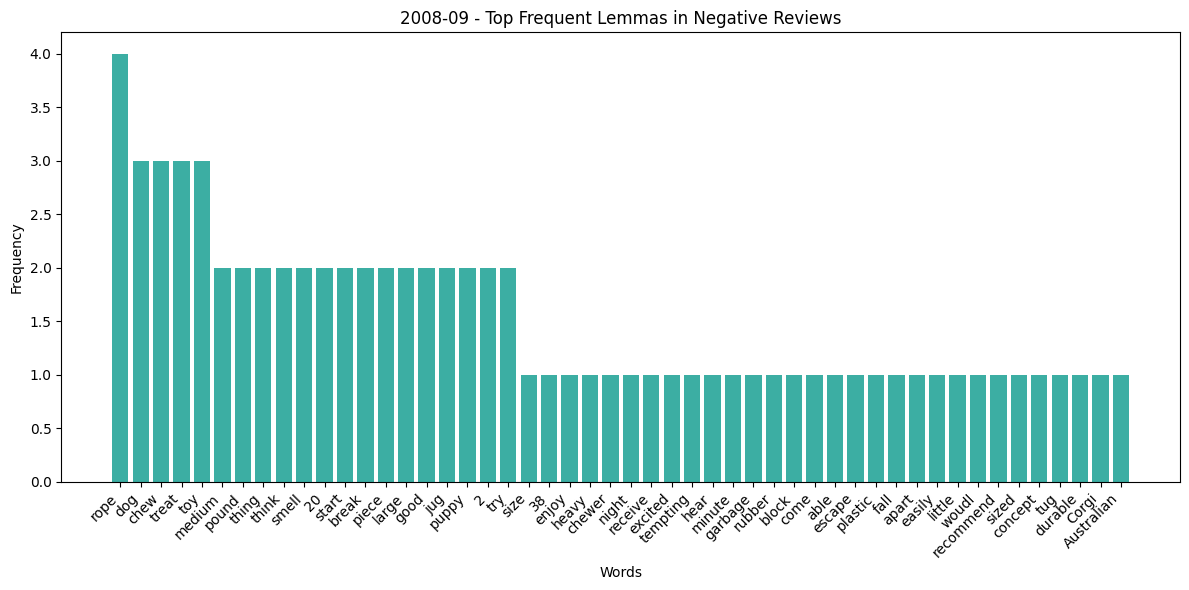


📅 Analyzing products ['B000VK8AVK', 'B001RVFERK', 'B007M832YY', 'B0013NUGDE', 'B001RVFEP2', 'B0026KPDG8', 'B007M83302', 'B0026KNQSA'] for 2011-01 (80 reviews total)
Lemma 頻率資料: [('chip', 72), ('salt', 32), ('Salt', 24), ('flavor', 24), ('box', 24), ('try', 16), ('Pepper', 16), ('healthy', 16), ('alternative', 16), ('great', 16), ('ricecake', 16), ('potato', 16), ('sodium', 16), ('serving', 16), ('special', 8), ('13', 8), ('24', 8), ('.8', 8), ('oz', 8), ('bag', 8), ('absolutely', 8), ('wonderful', 8), ('deal', 8), ('unfortunately', 8), ('Original', 8), ('BBQ', 8), ('Vinegar', 8), ('awful', 8), ('love', 8), ('Sour', 8), ('Cream', 8), ('Onion', 8), ('normally', 8), ('sure', 8), ('dislike', 8), ('hope', 8), ('return', 8), ('fanatic', 8), ('house', 8), ('decide', 8), ('claim', 8), ('regular', 8), ('admit', 8), ('crunch', 8), ('kettle', 8), ('texture', 8), ('nice', 8), ('similar', 8), ('big', 8), ('issue', 8)]


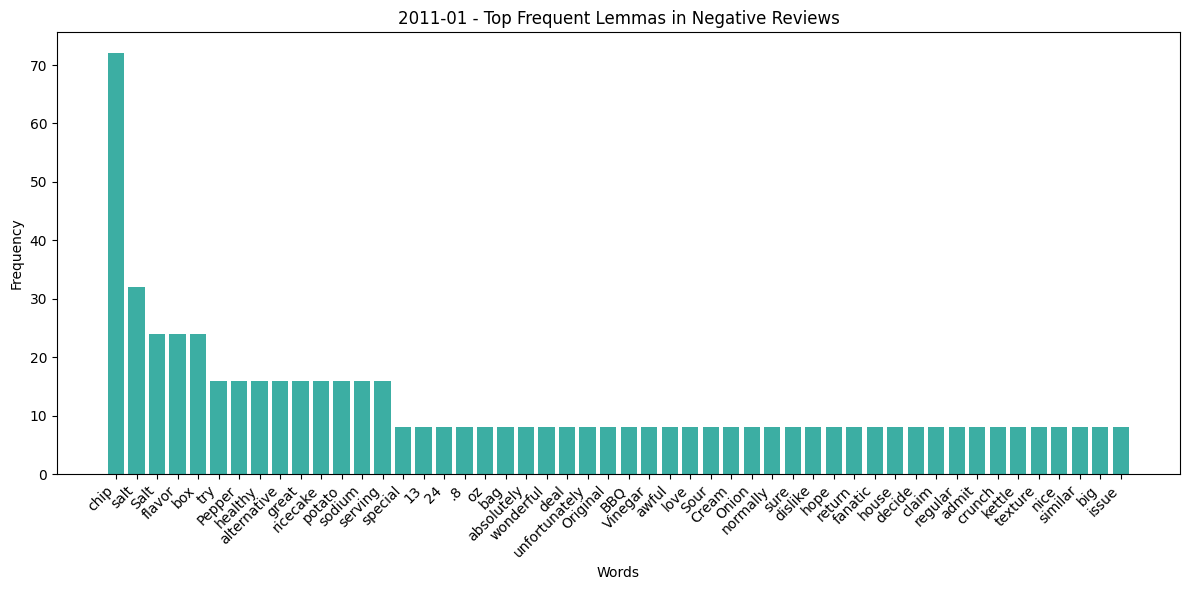

In [243]:


# 針對每個月份和產品ID進行分析
for ym, product_ids in query_conditions.items():
    year, month = map(int, ym.split("-"))
    reviews = find_reviews_by_product_and_time(reviews_col, product_ids, year, month)
    
    print(f"\n📅 Analyzing products {product_ids} for {ym} ({len(reviews)} reviews total)")
    
    # 計算低分評論中的 Lemma 頻率，並過濾掉不需要的停用詞
    lemma_freq = get_cleaned_negative_frequencies(reviews)
    
    # 檢查 Lemma 頻率資料
    print(f"Lemma 頻率資料: {lemma_freq}")
    
    # 如果 lemma_freq 有資料，才繪製圖表
    if lemma_freq:
        # 畫出高頻的 Lemma
        plot_top_words(lemma_freq, title=f"{ym} - Top Frequent Lemmas in Negative Reviews")
    else:
        print(f"{ym} 沒有找到 Lemma！")
